# Annual Revenue Plan by Segment

Builds a 12-month revenue plan by business segment from historical transactions:

1. **Base** — each plan month starts from the latest actual for the same calendar month (keeps seasonality) and grows it by the organic growth seen in the data.
2. **Uplift** — whatever the YoY target needs on top of the organic base is the expected effect of new initiatives, spread proportionally to the base.
3. **Direct Sales** — a manual stream added on top, outside the YoY target.
4. **Integrity** — everything is in whole pounds, rounding residuals are reconciled, and the plan is checked against the target.

The notebook is self-contained: every step from loading the data to the Excel export is in the cells below. [`revenue_plan.py`](revenue_plan.py) runs the same workflow in one command.

## 1. Business inputs

The YoY target is a business input, not a forecast. Change the values here and re-run the notebook.

In [1]:
import io
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from xlsxwriter.utility import xl_col_to_name

pd.options.display.float_format = "{:,.0f}".format

PLAN_START = "auto"          # "auto" = month after the last complete month, or "YYYY-MM-01"
PLAN_MONTHS = 12
YOY_TARGET = 1.25            # programmatic plan / previous 12 months
ORGANIC_GROWTH = "auto"      # "auto" = last 12 months / previous 12 months, or a number
DIRECT_SALES = [15_000] * PLAN_MONTHS  # manual plan, added on top of the YoY target

SEGMENTS = ["UK", "EU", "RoW"]
MANUAL_SEGMENT = "Direct_Sales"
ALL_SEGMENTS = SEGMENTS + [MANUAL_SEGMENT]

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load and clean the data

[Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) (UCI, CC BY 4.0): ~1M transactions of a UK online retailer, Dec 2009 – Dec 2011.

- Countries are grouped into **UK**, **EU** and **RoW** to stand in for product lines.
- Revenue is gross, in GBP: `Quantity × Price`.
- Excluded: cancellations (invoice starts with `C`), rows with non-positive quantity or price, exact duplicates, and non-product codes (postage, fees, manual adjustments, tests).

The raw file is ~45 MB, so the repo ships only the daily aggregate `data/daily_revenue.csv`. If it is missing, the cell downloads the source from UCI and rebuilds it.

In [2]:
UCI_URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
CACHE = DATA_DIR / "daily_revenue.csv"

EU_COUNTRIES = {
    "Austria", "Belgium", "Cyprus", "Czech Republic", "Denmark", "EIRE", "Finland",
    "France", "Germany", "Greece", "Italy", "Lithuania", "Malta", "Netherlands",
    "Poland", "Portugal", "Spain", "Sweden", "European Community",
}
NON_PRODUCT_CODES = {
    "POST", "DOT", "M", "C2", "D", "S", "B", "BANK CHARGES",
    "AMAZONFEE", "CRUK", "PADS", "ADJUST", "ADJUST2", "TEST001", "TEST002",
}


def download(url):
    with urllib.request.urlopen(url, timeout=120) as response:
        return response.read()


def load_raw():
    archive = zipfile.ZipFile(io.BytesIO(download(UCI_URL)))
    xlsx = next(name for name in archive.namelist() if name.endswith(".xlsx"))
    sheets = pd.read_excel(archive.open(xlsx), sheet_name=None, dtype={"Invoice": str, "StockCode": str})
    return pd.concat(sheets.values(), ignore_index=True)


def build_daily(raw):
    df = raw.drop_duplicates().copy()
    df["Invoice"] = df["Invoice"].astype(str)
    df["StockCode"] = df["StockCode"].astype(str).str.upper()
    df = df[
        ~df["Invoice"].str.startswith("C")
        & (df["Quantity"] > 0)
        & (df["Price"] > 0)
        & ~df["StockCode"].isin(NON_PRODUCT_CODES)
    ]
    df["date"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()
    df["segment"] = np.select(
        [df["Country"].eq("United Kingdom"), df["Country"].isin(EU_COUNTRIES)], ["UK", "EU"], default="RoW"
    )
    df["revenue"] = df["Quantity"] * df["Price"]
    return df.groupby(["date", "segment"], as_index=False)["revenue"].sum()


if CACHE.exists():
    daily = pd.read_csv(CACHE, parse_dates=["date"])
else:
    DATA_DIR.mkdir(exist_ok=True)
    daily = build_daily(load_raw())
    daily.to_csv(CACHE, index=False)

print(f"{daily['date'].min():%Y-%m-%d} → {daily['date'].max():%Y-%m-%d}, {len(daily):,} rows")
daily.head()

2009-12-01 → 2011-12-09, 1,442 rows


,date,segment,revenue
0,2009-12-01,EU,"5,981"
1,2009-12-01,RoW,196
2,2009-12-01,UK,"46,261"
3,2009-12-02,EU,"7,243"
4,2009-12-02,UK,"54,630"


## 3. Monthly history

Daily revenue is pivoted to months by segment. The data ends on 9 Dec 2011, so the trailing partial month is dropped.

In [3]:
monthly = (
    daily.assign(month=daily["date"].dt.to_period("M").dt.to_timestamp())
    .pivot_table(index="month", columns="segment", values="revenue", aggfunc="sum", fill_value=0)
    [SEGMENTS]
)
monthly["total"] = monthly.sum(axis=1)

last_day = daily["date"].max()
if last_day != last_day + pd.offsets.MonthEnd(0):
    monthly = monthly[monthly.index < last_day.to_period("M").to_timestamp()]

print(f"Complete months: {len(monthly)} ({monthly.index[0]:%Y-%m} – {monthly.index[-1]:%Y-%m})")
share = monthly[SEGMENTS].iloc[-12:].sum() / monthly["total"].iloc[-12:].sum()
print("Segment share, last 12 months:", ", ".join(f"{s} {v:.0%}" for s, v in share.items()))

monthly.tail(6).set_axis(monthly.tail(6).index.strftime("%Y-%m")).rename_axis(None)

Complete months: 24 (2009-12 – 2011-11)
Segment share, last 12 months: UK 85%, EU 12%, RoW 3%


segment,UK,EU,RoW,total
2011-06,"605,156","88,584","43,945","737,684"
2011-07,"577,182","89,954","21,116","688,253"
2011-08,"578,788","103,053","42,467","724,308"
2011-09,"876,076","128,119","24,150","1,028,345"
2011-10,"911,484","153,084","38,763","1,103,331"
2011-11,"1,280,863","139,396","31,858","1,452,116"


## 4. Plan horizon and organic growth

The plan covers the 12 months after the last complete month. Organic growth = revenue of the last 12 complete months / revenue of the 12 months before; one rate for all segments. With less than 24 months of history the base stays flat.

In [4]:
start = monthly.index[-1] + pd.offsets.MonthBegin(1) if PLAN_START == "auto" else pd.Timestamp(PLAN_START)
plan_months = pd.date_range(start, periods=PLAN_MONTHS, freq="MS")

if ORGANIC_GROWTH != "auto":
    organic_growth = float(ORGANIC_GROWTH)
elif len(monthly) < 24:
    print(f"Warning: only {len(monthly)} complete months of history; using organic growth 1.0")
    organic_growth = 1.0
else:
    organic_growth = monthly["total"].iloc[-12:].sum() / monthly["total"].iloc[-24:-12].sum()

print(f"Plan period:    {plan_months[0]:%Y-%m} – {plan_months[-1]:%Y-%m}")
print(f"Last 12 months: £{monthly['total'].iloc[-12:].sum():,.0f}")
print(f"Prior 12:       £{monthly['total'].iloc[-24:-12].sum():,.0f}")
print(f"Organic growth: ×{organic_growth:.4f}")

Plan period:    2011-12 – 2012-11
Last 12 months: £9,633,406
Prior 12:       £9,397,713
Organic growth: ×1.0251


## 5. Base by segment

For every plan month take the latest actual of the same calendar month, by segment, and grow it:

`base = same-month actual × organic_growth ^ years_between`

Here every source month is exactly one year back, so the base is last year's month × organic growth. Values are rounded to whole pounds.

In [5]:
source_rows = []
for month in plan_months:
    same_month = monthly[monthly.index.month == month.month]
    if same_month.empty:
        raise ValueError(f"No history for calendar month {month.month}")
    source_month = same_month.index.max()
    source_rows.append({
        "dt": month,
        "source_month": source_month,
        "lag_years": month.year - source_month.year,
        **{f"{s}_actual": same_month.loc[source_month, s] for s in SEGMENTS},
    })
base = pd.DataFrame(source_rows)

plan = pd.DataFrame({"dt": plan_months})
for s in SEGMENTS:
    plan[f"{s}_base"] = (base[f"{s}_actual"] * organic_growth ** base["lag_years"]).round()
programmatic_base = plan[[f"{s}_base" for s in SEGMENTS]].sum(axis=1)

pd.DataFrame({
    "plan month": plan_months.strftime("%Y-%m"),
    "source month": base["source_month"].dt.strftime("%Y-%m"),
    "last actual": base[[f"{s}_actual" for s in SEGMENTS]].sum(axis=1),
    **{f"{s} base": plan[f"{s}_base"] for s in SEGMENTS},
    "programmatic base": programmatic_base,
}).style.format("{:,.0f}", subset=pd.IndexSlice[:, ["last actual", "UK base", "EU base", "RoW base", "programmatic base"]]).hide(axis="index")

plan month,source month,last actual,UK base,EU base,RoW base,programmatic base
2011-12,2010-12,"775,715","722,998","56,884","15,288","795,170"
2012-01,2011-01,"670,439","559,604","106,577","21,073","687,254"
2012-02,2011-02,"507,867","428,442","64,443","27,719","520,604"
2012-03,2011-03,"689,842","585,794","97,918","23,431","707,143"
2012-04,2011-04,"515,470","477,055","35,760","15,583","528,398"
2012-05,2011-05,"740,036","633,771","100,778","24,047","758,596"
2012-06,2011-06,"737,684","620,333","90,805","45,047","756,185"
2012-07,2011-07,"688,253","591,658","92,210","21,646","705,514"
2012-08,2011-08,"724,308","593,304","105,638","43,532","742,474"
2012-09,2011-09,"1,028,345","898,048","131,332","24,756","1,054,136"


## 6. Uplift to the YoY target

The reference period is the 12 months before the plan year (here: exactly the last 12 actual months from section 4). The gap between `reference × YoY target` and the organic base is the uplift expected from new initiatives. It is distributed as the same % of the base in every month and segment.

In [6]:
last_year_total = sum(
    (base[f"{s}_actual"] * organic_growth ** (base["lag_years"] - 1)).sum() for s in SEGMENTS
)
target = last_year_total * YOY_TARGET
total_uplift = target - programmatic_base.sum()
if total_uplift < 0:
    print("Warning: organic growth alone is above the YoY target.")
uplift_rate = total_uplift / programmatic_base.sum()

pd.Series({
    "Reference period (previous 12 months)": last_year_total,
    f"Target (× {YOY_TARGET})": target,
    "Organic base": programmatic_base.sum(),
    "  of which organic growth": programmatic_base.sum() - last_year_total,
    "Uplift needed from initiatives": total_uplift,
}, name="GBP").to_frame().style.format("{:,.0f}").set_caption(f"Uplift rate on top of base: {uplift_rate:.2%}")

,GBP
Reference period (previous 12 months),"9,633,406"
Target (× 1.25),"12,041,757"
Organic base,"9,875,011"
of which organic growth,"241,605"
Uplift needed from initiatives,"2,166,746"


## 7. Rounding reconciliation

The plan is in whole pounds. Rounding each month and each segment independently leaves small residuals, so the sums would miss the target by a few pounds. Two fixes:

- **Yearly:** the residual between the rounded annual uplift and the sum of rounded monthly uplifts goes to the last month.
- **Monthly:** within each month, the last segment (RoW) takes whatever is left after the rounded UK and EU uplifts.

Which month and segment absorb the residual is a deterministic convention, not a modelling choice: the residual is at most ±£1.

The table shows the residual each month before reconciliation.

In [7]:
uplift = (programmatic_base * uplift_rate).round()
yearly_residual = round(total_uplift) - uplift.sum()
uplift.iloc[-1] += yearly_residual

independently_rounded = pd.DataFrame({s: (plan[f"{s}_base"] * uplift_rate).round() for s in SEGMENTS})
for s in SEGMENTS[:-1]:
    plan[f"{s}_uplift"] = independently_rounded[s]
plan[f"{SEGMENTS[-1]}_uplift"] = uplift - independently_rounded[SEGMENTS[:-1]].sum(axis=1)

print(f"Yearly residual moved to {plan_months[-1]:%b %Y}: {yearly_residual:+.0f} GBP")
pd.DataFrame({
    "month": plan_months.strftime("%Y-%m"),
    "monthly uplift": uplift,
    "sum of rounded segments": independently_rounded.sum(axis=1),
    f"residual → {SEGMENTS[-1]}": uplift - independently_rounded.sum(axis=1),
}).style.format("{:,.0f}", subset=["monthly uplift", "sum of rounded segments"]).format(
    "{:+.0f}", subset=[f"residual → {SEGMENTS[-1]}"]
).hide(axis="index")

Yearly residual moved to Nov 2012: +1 GBP


month,monthly uplift,sum of rounded segments,residual → RoW
2011-12,"174,474","174,473",+1
2012-01,"150,795","150,796",-1
2012-02,"114,229","114,230",-1
2012-03,"155,159","155,159",+0
2012-04,"115,940","115,939",+1
2012-05,"166,449","166,448",+1
2012-06,"165,920","165,920",+0
2012-07,"154,802","154,802",+0
2012-08,"162,911","162,912",-1
2012-09,"231,295","231,295",+0


## 8. Final plan

Direct Sales are added as a separate segment with no uplift. Every segment gets `base`, `uplift` and `total` columns; the plan line is the sum over segments.

In [8]:
plan[f"{MANUAL_SEGMENT}_base"] = DIRECT_SALES
plan[f"{MANUAL_SEGMENT}_uplift"] = 0
for s in ALL_SEGMENTS:
    plan[f"{s}_total"] = plan[f"{s}_base"] + plan[f"{s}_uplift"]

plan["base"] = plan[[f"{s}_base" for s in ALL_SEGMENTS]].sum(axis=1)
plan["uplift"] = uplift
plan["plan"] = plan["base"] + plan["uplift"]

columns = ["dt", "plan", "base", "uplift"] + [f"{s}_{kind}" for s in ALL_SEGMENTS for kind in ("total", "base", "uplift")]
plan = plan[columns].astype({c: "int64" for c in columns[1:]})
programmatic_plan = plan["plan"] - plan[f"{MANUAL_SEGMENT}_total"]

summary = plan[["dt"] + [f"{s}_total" for s in ALL_SEGMENTS] + ["base", "uplift", "plan"]].copy()
summary["dt"] = summary["dt"].dt.strftime("%Y-%m")
summary.columns = ["month", *[s.replace("_", " ") for s in ALL_SEGMENTS], "base", "uplift", "total plan"]
summary.loc[len(summary)] = ["TOTAL", *summary.iloc[:, 1:].sum()]
summary.style.format("{:,.0f}", subset=summary.columns[1:]).hide(axis="index")

month,UK,EU,RoW,Direct Sales,base,uplift,total plan
2011-12,"881,636","69,365","18,643","15,000","810,170","174,474","984,644"
2012-01,"682,391","129,962","25,696","15,000","702,254","150,795","853,049"
2012-02,"522,450","78,583","33,800","15,000","535,604","114,229","649,833"
2012-03,"714,327","119,403","28,572","15,000","722,143","155,159","877,302"
2012-04,"581,729","43,606","19,003","15,000","543,398","115,940","659,338"
2012-05,"772,831","122,890","29,324","15,000","773,596","166,449","940,045"
2012-06,"756,445","110,729","54,931","15,000","771,185","165,920","937,105"
2012-07,"721,478","112,442","26,396","15,000","720,514","154,802","875,316"
2012-08,"723,485","128,817","53,083","15,000","757,474","162,911","920,385"
2012-09,"1,095,095","160,148","30,188","15,000","1,069,136","231,295","1,300,431"


## 9. Validation

Segments must add up to every plan line in every month, and the programmatic plan must hit the YoY target to the pound.

In [9]:
for kind, line in (("total", "plan"), ("base", "base"), ("uplift", "uplift")):
    segments_sum = plan[[f"{s}_{kind}" for s in ALL_SEGMENTS]].sum(axis=1)
    assert (segments_sum == plan[line]).all(), f"Segment {kind} does not add up to {line}"
assert (plan["plan"] == plan["base"] + plan["uplift"]).all()

achieved_yoy = programmatic_plan.sum() / last_year_total
assert abs(achieved_yoy - YOY_TARGET) < 1e-6, achieved_yoy

print("Programmatic, GBP")
print(f"  Previous 12 months: {last_year_total:>14,.0f}")
print(f"  Organic growth:     {programmatic_base.sum() - last_year_total:>14,.0f}")
print(f"  Initiatives uplift: {plan['uplift'].sum():>14,.0f}")
print(f"  Plan:               {programmatic_plan.sum():>14,.0f}   (YoY ×{achieved_yoy:.3f}, target ×{YOY_TARGET})")
print(f"Direct Sales:         {plan[f'{MANUAL_SEGMENT}_total'].sum():>14,.0f}")
print(f"Total plan:           {plan['plan'].sum():>14,.0f}")
print("All checks passed ✓")

Programmatic, GBP
  Previous 12 months:      9,633,406
  Organic growth:            241,605
  Initiatives uplift:      2,166,746
  Plan:                   12,041,757   (YoY ×1.250, target ×1.25)
Direct Sales:                180,000
Total plan:               12,221,757
All checks passed ✓


## 10. Visualisation

Left: actual programmatic revenue, the organic base and the plan; the shaded band is the initiatives uplift. Right: the total monthly plan by segment, Direct Sales on top.

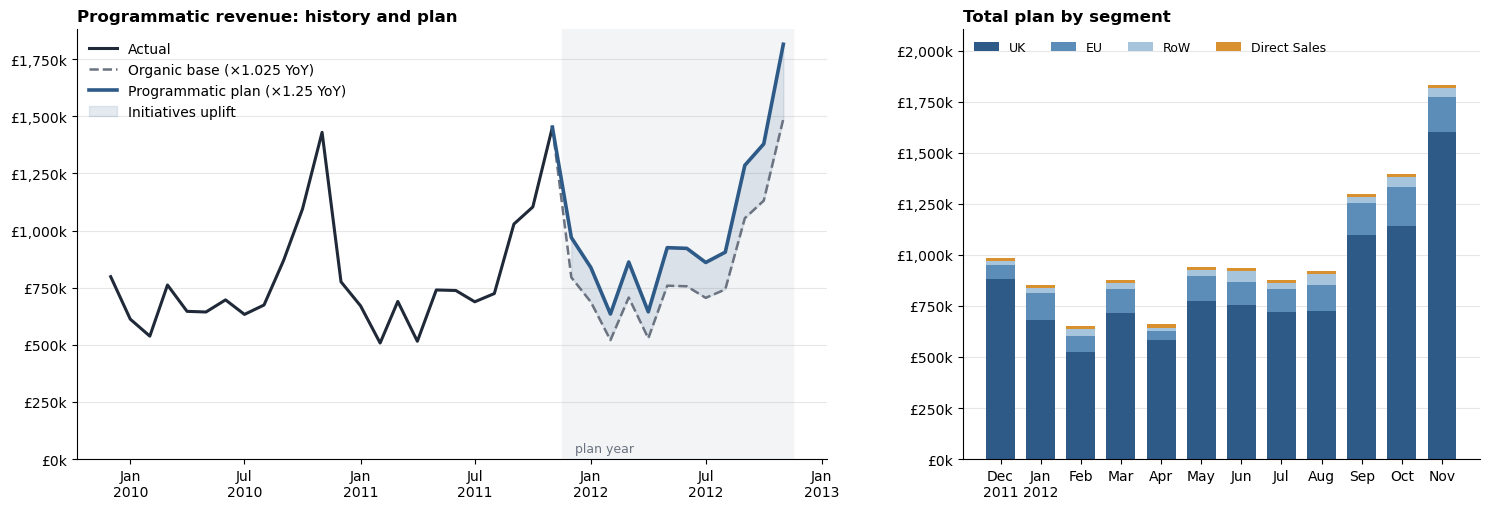

In [10]:
colors = {"UK": "#2E5A88", "EU": "#5B8DB8", "RoW": "#A7C4DD", MANUAL_SEGMENT: "#D9902F"}
fmt_k = mtick.FuncFormatter(lambda x, _: f"£{x / 1e3:,.0f}k")

fig, (ax_line, ax_bar) = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.45, 1]})

# Left: actuals, then base and plan starting from the last actual month
link = monthly.index[-1:].append(pd.DatetimeIndex(plan["dt"]))
last_actual = monthly["total"].iloc[-1]
ax_line.plot(monthly.index, monthly["total"], color="#1F2937", lw=2.2, label="Actual")
ax_line.plot(link, np.r_[last_actual, programmatic_base], color="#6B7280", lw=1.8, ls="--",
             label=f"Organic base (×{organic_growth:.3f} YoY)")
ax_line.plot(link, np.r_[last_actual, programmatic_plan], color="#2E5A88", lw=2.6,
             label=f"Programmatic plan (×{YOY_TARGET} YoY)")
ax_line.fill_between(plan["dt"], programmatic_base, programmatic_plan, color="#2E5A88", alpha=0.12,
                     label="Initiatives uplift")
ax_line.axvspan(plan["dt"].iloc[0] - pd.Timedelta(days=15), plan["dt"].iloc[-1] + pd.Timedelta(days=15),
                color="#F3F4F6", zorder=0)
ax_line.text(plan["dt"].iloc[0], 30_000, " plan year", color="#6B7280", fontsize=9)
ax_line.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
ax_line.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax_line.set_ylim(0, None)
ax_line.set_title("Programmatic revenue: history and plan", loc="left", fontweight="bold")
ax_line.legend(frameon=False, loc="upper left")

# Right: total plan by segment, Direct Sales on top
labels = [f"{d:%b}\n{d:%Y}" if i == 0 or d.month == 1 else f"{d:%b}" for i, d in enumerate(plan["dt"])]
bottom = np.zeros(len(plan))
for s in ALL_SEGMENTS:
    values = plan[f"{s}_total"].to_numpy()
    ax_bar.bar(labels, values, bottom=bottom, color=colors[s], width=0.72, label=s.replace("_", " "))
    bottom += values
ax_bar.set_title("Total plan by segment", loc="left", fontweight="bold")
ax_bar.legend(frameon=False, ncol=4, loc="upper left", fontsize=9)
ax_bar.set_ylim(0, bottom.max() * 1.15)

for ax in (ax_line, ax_bar):
    ax.yaxis.set_major_formatter(fmt_k)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)

fig.tight_layout(w_pad=4)
fig.savefig(OUTPUT_DIR / "plan_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Export to Excel

Three sheets:
- **Plan** — monthly plan by segment with base / uplift / total, a TOTAL row with `SUM` formulas, frozen header and month column.
- **Assumptions** — plan and reference periods, target, organic growth, uplift rate, Direct Sales.
- **History** — monthly actuals by segment.

In [11]:
xlsx_path = OUTPUT_DIR / f"revenue_plan_{plan_months[0]:%Y-%m}_{plan_months[-1]:%Y-%m}.xlsx"

with pd.ExcelWriter(xlsx_path, engine="xlsxwriter") as writer:
    workbook = writer.book
    header = workbook.add_format({
        "bold": True, "font_color": "white", "bg_color": "#2F3E52",
        "align": "center", "valign": "vcenter", "text_wrap": True, "border": 1,
    })
    number = workbook.add_format({"num_format": "#,##0", "border": 1})
    month_format = workbook.add_format({"num_format": "mmm yyyy", "border": 1, "align": "center"})
    total_format = workbook.add_format({"num_format": "#,##0", "border": 1, "bold": True, "bg_color": "#EDEFF2"})

    # Plan
    sheet = workbook.add_worksheet("Plan")
    for col, name in enumerate(columns):
        sheet.write(0, col, "month" if name == "dt" else name.replace("_", " "), header)
    for row, record in enumerate(plan.itertuples(index=False), start=1):
        sheet.write_datetime(row, 0, record[0].to_pydatetime(), month_format)
        for col, value in enumerate(record[1:], start=1):
            sheet.write_number(row, col, value, number)
    total_row = len(plan) + 1
    sheet.write(total_row, 0, "TOTAL", total_format)
    for col, name in enumerate(columns[1:], start=1):
        letter = xl_col_to_name(col)
        sheet.write_formula(total_row, col, f"=SUM({letter}2:{letter}{total_row})", total_format, plan[name].sum())
    sheet.set_row(0, 32)
    sheet.set_column(0, 0, 11)
    sheet.set_column(1, len(columns) - 1, 13)
    sheet.freeze_panes(1, 1)

    # Assumptions
    reference = f"{plan_months[0] - pd.DateOffset(years=1):%Y-%m} – {plan_months[-1] - pd.DateOffset(years=1):%Y-%m}"
    pd.DataFrame({
        "parameter": [
            "Revenue", "Plan period", "Reference period (YoY)", "YoY target",
            "Organic growth per year", "Uplift on top of base", "Direct Sales, year",
        ],
        "value": [
            "gross, GBP", f"{plan_months[0]:%Y-%m} – {plan_months[-1]:%Y-%m}", reference,
            YOY_TARGET, round(organic_growth, 4), f"{uplift_rate:.2%}", sum(DIRECT_SALES),
        ],
    }).to_excel(writer, sheet_name="Assumptions", index=False)
    writer.sheets["Assumptions"].set_column(0, 1, 26)

    # History
    history = monthly.round(0).astype("int64").reset_index()
    history["month"] = history["month"].dt.strftime("%Y-%m")
    history.to_excel(writer, sheet_name="History", index=False)

print(f"Saved → {xlsx_path.as_posix()}")

Saved → output/revenue_plan_2011-12_2012-11.xlsx


## Assumptions and limitations

- One organic-growth rate for all segments and months; it needs 24 complete months of history, otherwise the base stays flat.
- The uplift is the same % of the base every month: initiatives do not ramp up during the year.
- Direct Sales are a manual input outside the YoY target.
- Revenue is gross: cancellations are excluded, not netted off.